# Actividad corta: Ridge vs. Lasso

Van a comparar las dos formas de regularización que vieron en las diapositivas de "Evaluación y diagnóstico" (regresión con costo regularizado): **Ridge (L2)** y **Lasso (L1)**.

Las dos hacen lo mismo en el fondo — le suman una penalización al costo del modelo por tener coeficientes grandes, para reducir el sobreajuste — pero se comportan muy distinto en la práctica:

- **Ridge** encoge todos los coeficientes hacia cero, pero (casi) nunca los deja exactamente en cero.
- **Lasso** puede volver algunos coeficientes **exactamente cero** — en la práctica, hace selección de features automáticamente, como parte del proceso de ajuste.

Van a usar el mismo dataset de diabetes de siempre. Si ya hicieron la actividad de Multicolinealidad, esto va a cerrar una pregunta que quedó abierta ahí.

In [1]:
# ============================================================
# PREPARACIÓN — no modifiquen esta celda
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:       ", X_test.shape)

Tamaño de entrenamiento: (353, 10)
Tamaño de prueba:        (89, 10)


## Punto de partida: el modelo sin regularizar

Como referencia rápida, así se ven los coeficientes de una regresión lineal normal (sin penalización). Fíjense otra vez en `s1` y `s2` — si ya vieron la actividad de Multicolinealidad, van a reconocer estos números.

In [2]:
modelo_base = LinearRegression()
modelo_base.fit(X_train, y_train)

for feat, coef in zip(X_train.columns, modelo_base.coef_):
    print(f"  {feat:>4}: {coef:>10.2f}")

mse_base = mean_squared_error(y_test, modelo_base.predict(X_test))
print(f"\nMSE test (sin regularizar): {mse_base:.2f}")

   age:      37.90
   sex:    -241.96
   bmi:     542.43
    bp:     347.70
    s1:    -931.49
    s2:     518.06
    s3:     163.42
    s4:     275.32
    s5:     736.20
    s6:      48.67

MSE test (sin regularizar): 2900.19


## Parte A — El camino de regularización (regularization path)

Vamos a ajustar Ridge y Lasso muchas veces, cada vez con un `alpha` (fuerza de la regularización) distinto, de muy chico a más grande, y vamos a graficar cómo se mueve cada coeficiente conforme sube `alpha`. Esta gráfica se llama comúnmente "regularization path" — es de las más clásicas en Machine Learning (la van a reconocer si hojean el libro *Introduction to Statistical Learning*, capítulo de regularización).

La celda ya está lista — solo córranla y observen.

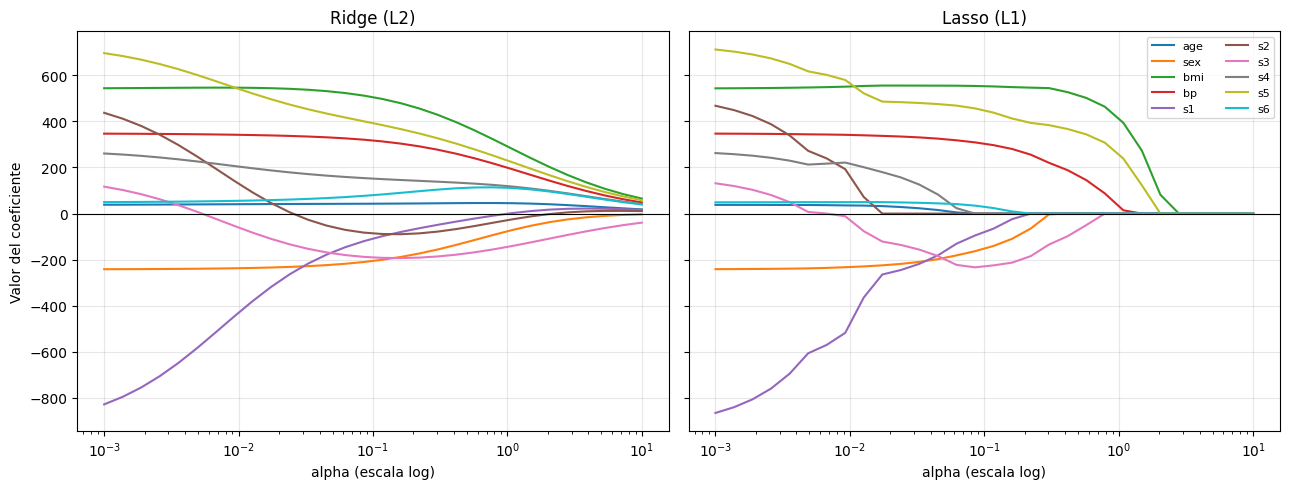

In [3]:
alphas = np.logspace(-3, 1, 30)  # de 0.001 a 10

coefs_ridge = []
coefs_lasso = []
for a in alphas:
    r = Ridge(alpha=a).fit(X_train, y_train)
    l = Lasso(alpha=a, max_iter=20000).fit(X_train, y_train)
    coefs_ridge.append(r.coef_)
    coefs_lasso.append(l.coef_)

coefs_ridge = np.array(coefs_ridge)
coefs_lasso = np.array(coefs_lasso)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for i, feat in enumerate(X_train.columns):
    axes[0].plot(alphas, coefs_ridge[:, i], label=feat)
    axes[1].plot(alphas, coefs_lasso[:, i], label=feat)

for ax, titulo in zip(axes, ["Ridge (L2)", "Lasso (L1)"]):
    ax.set_xscale("log")
    ax.set_xlabel("alpha (escala log)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(titulo)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Valor del coeficiente")
axes[1].legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

**¿Qué observan?** En el panel de Ridge (izquierda), todas las líneas se acercan a cero conforme crece `alpha`, pero ninguna la toca — se van "apachurrando" gradualmente. En el panel de Lasso (derecha), varias líneas literalmente tocan el cero y se quedan ahí (planas) el resto del camino — esas son las features que Lasso "apagó" por completo en ese punto.

## Parte B — ¿Cuál conviene usar? Deja que la cross-validation decida

En vez de escoger `alpha` a ojo, usamos `LassoCV`, que prueba muchos valores de `alpha` con validación cruzada internamente y se queda con el que da mejor desempeño — el mismo patrón de "que el método decida por ti" que ya vieron con `RFECV`.

In [4]:
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_cv.fit(X_train, y_train)

print(f"alpha óptimo (elegido por cross-validation): {lasso_cv.alpha_:.4f}")
print()
for feat, coef in zip(X_train.columns, lasso_cv.coef_):
    marca = "  <-- eliminada" if abs(coef) < 1e-6 else ""
    print(f"  {feat:>4}: {coef:>10.2f}{marca}")

mse_lasso = mean_squared_error(y_test, lasso_cv.predict(X_test))
print(f"\nMSE test (Lasso, alpha óptimo): {mse_lasso:.2f}")
print(f"MSE test (sin regularizar):      {mse_base:.2f}")

alpha óptimo (elegido por cross-validation): 0.0781

   age:       0.00  <-- eliminada
   sex:    -168.17
   bmi:     554.13
    bp:     311.63
    s1:    -101.86
    s2:      -0.00  <-- eliminada
    s3:    -235.14
    s4:       0.00  <-- eliminada
    s5:     460.59
    s6:      36.92

MSE test (Lasso, alpha óptimo): 2800.26
MSE test (sin regularizar):      2900.19


## Para discutir

1. En la gráfica de la Parte A, ¿cuál de las dos variables del par redundante (`s1` o `s2`) llega primero a cero en el camino de Lasso? ¿Coincide con lo que ya sabían de la actividad de Multicolinealidad (VIF, bootstrap)?

2. Comparen el MSE de prueba del modelo sin regularizar contra el de `LassoCV`. ¿Mejoró, empeoró, o se quedó casi igual? ¿Qué les dice eso sobre si el modelo sin regularizar estaba sobreajustando?

3. Además de la variable redundante, `LassoCV` seguramente eliminó una o dos variables más. ¿Tiene sentido que las haya eliminado, considerando lo que ya saben de sus correlaciones individuales con el target?

4. Si tu objetivo fuera **explicarle a alguien** qué variables importan para predecir el avance de la diabetes (interpretabilidad), ¿usarías Ridge o Lasso? ¿Y si tu único objetivo fuera **predecir lo mejor posible**, sin que te importe cuántas variables usa el modelo?

5. Ridge nunca elimina variables — solo las encoge. ¿En qué situación preferirías eso, en vez del comportamiento de Lasso?